# 

The purpose of this notebook is to practice using threeML by replicating the process discussed by J. Michael Burgess, described in his blog: 
https://jmichaelburgess.com/fits_files/

Last updated: 09-15-2025

In [257]:
import numpy as np

%matplotlib notebook
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, LinearSegmentedColormap

import astropy.io.fits as fits
from astropy import units as u
from astropy.time import Time
from astropy.timeseries import TimeSeries
from astropy.table import vstack

from specutils import Spectrum1D

from astromodels.functions import Gaussian, Constant
from astromodels import Model, PointSource

from padre_meddea.io.file_tools import read_raw_file
from padre_meddea.io.file_tools import read_file
import padre_meddea.calibration.calibration as calibration

from padre_meddea.util.pixels import PixelList
from padre_meddea.spectrum.spectrum import PhotonList
import padre_meddea.util.pixels as pixels
import padre_meddea.spectrum.calibration as cal

from threeML import Model, PointSource, DataList, JointLikelihood, DispersionSpectrumLike
from functools import reduce
import operator


from threeML.utils.spectrum.binned_spectrum import BinnedSpectrumWithDispersion
from threeML.utils.OGIP.response import OGIPResponse

from corner import hist2d

from astromodels.functions import Gaussian, Constant
from astromodels import Parameter

import operator
from functools import reduce

import warnings

warnings.simplefilter("ignore")
np.seterr(all="ignore")

{'divide': 'ignore', 'over': 'ignore', 'under': 'ignore', 'invalid': 'ignore'}

J. Michael Burgess uses sample data from the Fermi Gamma-ray Burst Monitor (GBM) that has been reduced from its non-standard format into OGIP compliant FITS files. In his tutorial (https://jmichaelburgess.com/fits_files/), he uses a file called 'example.pha'. The specific file that he uses is not known, and I have not been able to contact him at the email address or social media links provided on his website to ask.

This file, 'example.pha' must have been a Fermi GBM Daily Data Product, since such files are the only ones that are PHA FITS files. Extra steps are required to obtain these files, and additional software may be required to parse them. 

Here, I want to use the same method that the author describes and apply it to MeDDEA data instead. 3ML expects measurements to be in OGIP-compliant .pha format, or at least in a format in which counts, energy bins, and exposure (i.e. integration time) are clearly defined. 

Read in the data (Ba133 source, -20C calibration data).

In [ ]:
# Create fits files to use.
#calibration.process_file('data/padre_meddea_l0test_calba_20250130T104700_v0.3.0.bin', overwrite=True)

In [ ]:
# Data to use.
filename = 'padre_meddea_l0test_photon_20250130T104655_v0.1.0.fits'

In [4]:
def read_data(filename): 
    ph_list = read_file(filename)

    all_pixel_list = PixelList().all()
    lin_cal_params = cal.calibrate_phlist_barium_linear(ph_list)
    cal_ph_list = cal.calibrate_linear_phlist(ph_list, lin_cal_params)

    #spec = cal_ph_list.spectrum(pixel_list=all_pixel_list)
    cal_spec = cal_ph_list.spectrum(pixel_list=all_pixel_list, calibrate=True)

    return cal_ph_list, cal_spec

In [5]:
cal_ph_list, cal_spec = read_data(filename=filename)

Select the times with minimal microphonics. 

In [6]:
ba_hk_ts, ba_cmd_ts = read_file('padre_meddea_l0test_housekeeping_20250130T104656_v0.1.0.fits')

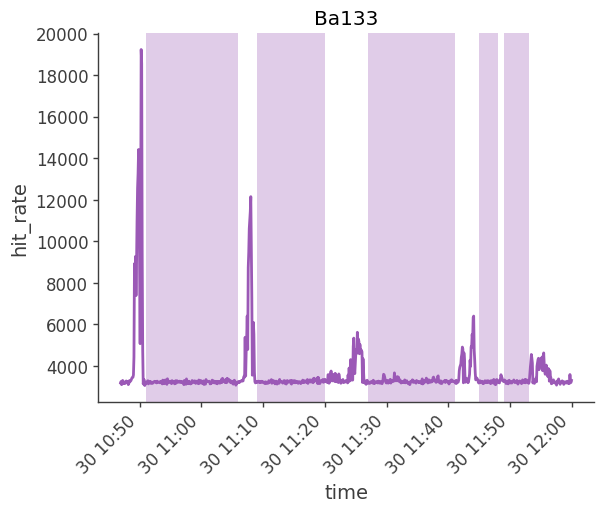

Total integration time for this measurement: 2819.999999999995 seconds.


In [215]:
# Plot the hit_rate to see which intervals are not dominated by microphonics. 
plt.plot(ba_hk_ts.time.to_datetime(), ba_hk_ts['hit_rate'])
plt.xticks(rotation=45, ha='right') 
plt.title('Ba133')
plt.ylabel('hit_rate')
plt.xlabel('time')

# Select intervals that are not dominated by microphonics. 
good_tr = [(Time('2025-01-30T10:51'), Time('2025-01-30T11:06')),
           (Time('2025-01-30T11:09'), Time('2025-01-30T11:20')),
           (Time('2025-01-30T11:27'), Time('2025-01-30T11:41')),
           (Time('2025-01-30T11:45'), Time('2025-01-30T11:48')),
           (Time('2025-01-30T11:49'), Time('2025-01-30T11:53'))]

# We will need the integration time (in seconds) when we define the observed spectrum in 3ML. 
# 3ML needs the integration time, the counts, and the energy bins for the measured spectrum. 
int_time = 0
for this_tr in good_tr: 
    plt.axvspan(this_tr[0].to_datetime(), this_tr[1].to_datetime(), alpha=0.3)
    int_time += (this_tr[1] - this_tr[0]).to_value('sec')
plt.show()

print(f'Total integration time for this measurement: {int_time} seconds.')

In [ ]:
# Combine the subsets of the ph_list that correspond to the highlighted times. 
def filter_and_combine_photon_list(photon_list, time_ranges):
    '''
    Filter a photon list based on time ranges and combine the results. 
    
    Parameters:
    -----------
    photon_list: object 
        The photon list to filter. 

    time_ranges : list
        List of (start_time, end_time) tuples, defining time ranges to keep. 
        
    Returns:
    --------
    combined_photon_list : object
        A new photon list with data from only the specified time ranges. 
    '''
    
    event_list = photon_list.event_list
    pkt_list = photon_list.pkt_list
    
    print(f"Successfully accessed event_list with {len(event_list)} events")
    print(f"Successfully accessed pkt_list with {len(pkt_list)} packets")
    
    # Filter the event_list for each time range and collect results
    filtered_events = []
    for start_time, end_time in time_ranges:
        print(f"Filtering events for time range: {start_time} to {end_time}")
        
        # Create time mask for this range
        event_mask = ((event_list.time >= start_time) & (event_list.time <= end_time))
        
        # Filter the events
        filtered_subset = event_list[event_mask]
        if len(filtered_subset) > 0:
            filtered_events.append(filtered_subset)
            print(f"  Added {len(filtered_subset)} events")
        else:
            print("  No events found in this time range")
    
    # Combine filtered events
    if filtered_events:
        combined_events = vstack(filtered_events)
        print(f"Combined events: {len(combined_events)} total events")
    else:
        print("No events found in any of the specified time ranges")
        return None
    
    # Filter the pkt_list for each time range and collect results
    filtered_pkts = []
    for start_time, end_time in time_ranges:
        print(f"Filtering packets for time range: {start_time} to {end_time}")
        
        # Create time mask for this range
        pkt_mask = ((pkt_list.time >= start_time) & (pkt_list.time <= end_time))
        
        # Filter the packets
        filtered_subset = pkt_list[pkt_mask]
        if len(filtered_subset) > 0:
            filtered_pkts.append(filtered_subset)
            print(f"  Added {len(filtered_subset)} packets")
        else:
            print("  No packets found in this time range")
    
    # Combine all filtered packets
    if filtered_pkts:
        combined_pkts = vstack(filtered_pkts)
        print(f"Combined packets: {len(combined_pkts)} total packets")
    else:
        print("No packets found in any of the specified time ranges")
        return None
    
    filtered_photon_list = PhotonList(event_list=combined_events, pkt_list=combined_pkts)
    
    return filtered_photon_list

In [190]:
filtered_ph_list = filter_and_combine_photon_list(cal_ph_list, good_tr)

print("\nFiltered PhotonList:")
print(f"Event count: {len(filtered_ph_list.event_list)}")
print(f"Packet count: {len(filtered_ph_list.pkt_list)}")
print(f"Time range: {filtered_ph_list.event_list.time.min().to_datetime()} - {filtered_ph_list.event_list.time.max().to_datetime()}")

Successfully accessed event_list with 7048844 events
Successfully accessed pkt_list with 49217 packets
Filtering events for time range: 2025-01-30T10:51:00.000 to 2025-01-30T11:06:00.000
  Added 1437017 events
Filtering events for time range: 2025-01-30T11:09:00.000 to 2025-01-30T11:20:00.000
  Added 1054624 events
Filtering events for time range: 2025-01-30T11:27:00.000 to 2025-01-30T11:41:00.000
  Added 1345586 events
Filtering events for time range: 2025-01-30T11:45:00.000 to 2025-01-30T11:48:00.000
  Added 288222 events
Filtering events for time range: 2025-01-30T11:49:00.000 to 2025-01-30T11:53:00.000
  Added 383455 events
Combined events: 4508904 total events
Filtering packets for time range: 2025-01-30T10:51:00.000 to 2025-01-30T11:06:00.000
  Added 10044 packets
Filtering packets for time range: 2025-01-30T11:09:00.000 to 2025-01-30T11:20:00.000
  Added 7370 packets
Filtering packets for time range: 2025-01-30T11:27:00.000 to 2025-01-30T11:41:00.000
  Added 9404 packets
Filteri

In [201]:
all_pixel_list = PixelList().all()

In [203]:
cal_spec = filtered_ph_list.spectrum(pixel_list=all_pixel_list, calibrate=True)

<WCSAxes: ylabel='Data [ct]'>

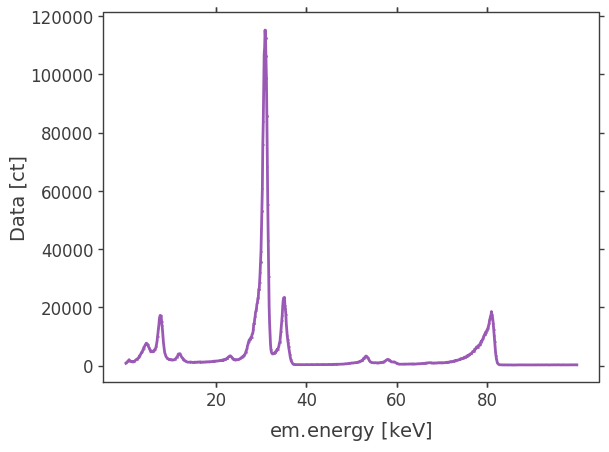

In [204]:
cal_spec.plot()

In [ ]:
# Save the energy and flux data from the calibrated and filtered calibrated event lists for ease of access. 
np.savez_compressed('calibrated_filtered_ba133_data.npz', energy=cal_spec.spectral_axis.value, flux=cal_spec.flux.value)

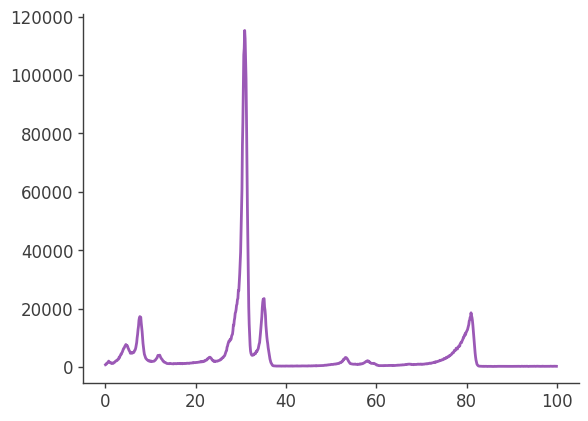

In [206]:
# Check that this worked. 
calibrated_filtered_ba133_data = np.load('calibrated_filtered_ba133_data.npz')
plt.plot(calibrated_filtered_ba133_data['energy'], calibrated_filtered_ba133_data['flux'])

Unlike the tutorial, we do not have a .rsp detector response file for MeDDEA, but we do have separate ARF and RMF files, each in an OGIP-compliant fits format. We can use these to construct the DRM. 

In [170]:
arf_file = 'MeDDEA_ARF.arf'
rmf_file = 'MeDDEA_RMF.rmf'

rsp = OGIPResponse(rmf_file, arf_file)
arf = rsp.arf
rmf = rsp.rmf
drm = rsp.matrix

Because the measured data will be compared to the folded counts (source model convolved with the DRM), rebin the measured data to match the energy range and energy bins of the DRM. 

In [228]:
def rebin_spec(ph_list, rsp, num_bins, asic, pixel, plot=None): 
    '''
    Rebin photon count data. 
    
    Parameters:
    -----------
    photon_list: object 
        The photon list to rebin and plot. 

    rsp: object 
        OGIP compliant detector response. 

    num_bins: int
        The number of energy bins in the rebinned counts vs. energy bins histogram. 

    asic: int
        ASIC number.

    pixel: int
        Pixel number.

    plot: boolean
        If True, plot the rebinned spectrum. 

    Returns:
    --------
    hist: counts
        The counts per energy bin of the rebinned spectrum. 
    
    bin_centers: array
        The locations of the centers of the energy bins. 
    
    energy_min: float
        The minimum energy included in the DRM. 
    
    energy_max: float
        The maximum energy included in the DRM.
    
    spectrum: Spectrum1D
        The rebinned spectrum. 
    '''

    # The dimensions must match those of the DRM. 
    # The monte_carlo_energies are the energies used in the simulation that produced the DRM. 
    num_bins = num_bins
    bins = np.linspace(rsp.monte_carlo_energies[0], rsp.monte_carlo_energies[-1], num_bins +1) # "+1' to account for the edge of the final bin. 

    # Rebin the data. 
    if (pixel != None) & (asic != None): 
        # Spectrum for individual pixel for an individual asic.
        energies = ph_list.event_list[(filtered_ph_list.event_list['asic']==asic) & (ph_list.event_list['pixel']==pixel)]['energy']
    
    if asic != None: 
        # Aggregate spectrum across all pixels for each asic.
        energies = ph_list.event_list[(filtered_ph_list.event_list['asic']==asic)]['energy']

    else: 
        # Aggregate spectrum across all four asics.
        energies = ph_list.event_list['energy']
    
    hist, bin_edges = np.histogram(energies, bins=bins)
    energy_min = bin_edges[:-1]
    energy_max = bin_edges[1:]

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    spectrum = Spectrum1D(
        flux=hist * u.ct,  # counts per bin
        spectral_axis=bin_centers * u.keV  # assumes energy is in keV
    )

    if plot == True:
        # Plot the measured data.
        plt.step(bin_centers, hist, where='mid')
        plt.xlabel("Energy (keV)")
        plt.ylabel("Counts")
        plt.title("Measured Spectrum (Rebinned)")
        plt.grid()
        plt.show()

    return hist, bin_centers, energy_min, energy_max, spectrum

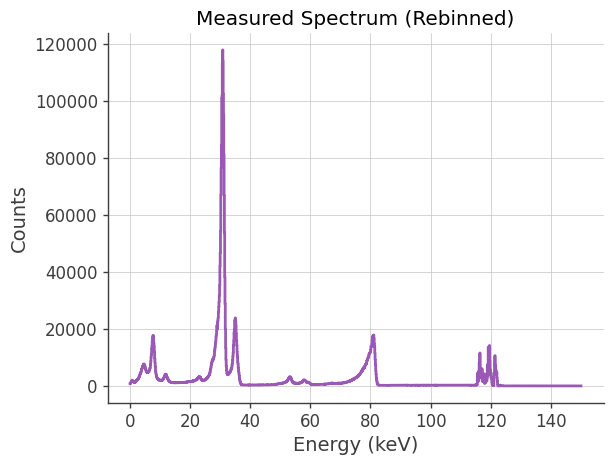

In [227]:
hist, bin_centers, energy_min, energy_max, cal_spec = rebin_spec(filtered_ph_list, rsp, num_bins=1500, asic=None, pixel=None, plot=True)

In [223]:
# Verify that the peaks at ~ 120 keV are as expected. 
#print(filtered_ph_list.event_list['energy'][filtered_ph_list.event_list['energy'] > 115.])

Great! the data have been rebinned, and the spectrum looks like what we expect. Indeed, the peaks at ~ 120 keV are as expected. 

Now, try the example in the tutorial (plotting the count rate divided by the energy per bin).

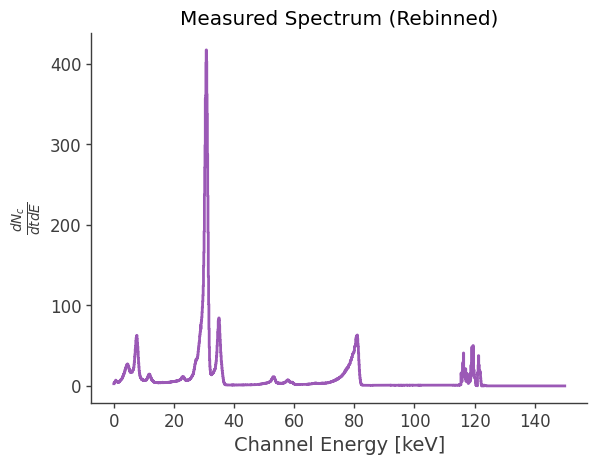

In [230]:
dNc_dt = hist / int_time
Nc = hist
dt = int_time
edges = np.append(energy_min, energy_max[-1])
dE = np.diff(edges)

def rate_plot(ax,bin_edges,rate,label=None):

    ax.step(bin_edges[:-1],rate,where='pre', label=label)

    #ax.set_xscale('log')
    #ax.set_yscale('log')
	
    ax.set_xlabel('Channel Energy [keV]')
    ax.set_ylabel(r'$\frac{d N_c}{dt dE}$')
    plt.title('Measured Spectrum (Rebinned)')

#dNc_dtdE = dNc_dt/dE * dE * dt
dNc_dtdE = dNc_dt/dE # same as before, but divided by the energy per bin and by the total integration time.
fig, ax = plt.subplots()
rate_plot(ax,edges,dNc_dtdE)

This is a Barium 133 spectrum measured by MeDDEA. We cannot simply apply the DRM to this spectrum however, because this spectrum includes detector effects! What we need to do is to create a model Barium 133 spectrum to which we can apply the DRM and fit the convolved result to the measured result. 

Text(0.5, 0, 'Photon Energy')

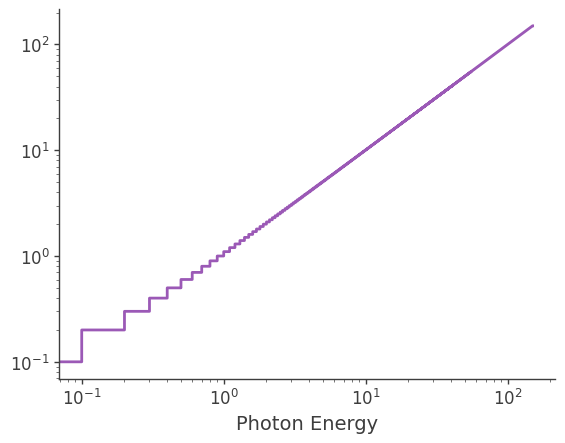

In [231]:
fig, ax = plt.subplots()

ax.step(rsp.monte_carlo_energies[:-1], rsp.monte_carlo_energies[:-1], where='pre')

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel('Photon Energy')
#ax.set_ylabel(r'$\frac{d N_p}{dt dA}$')

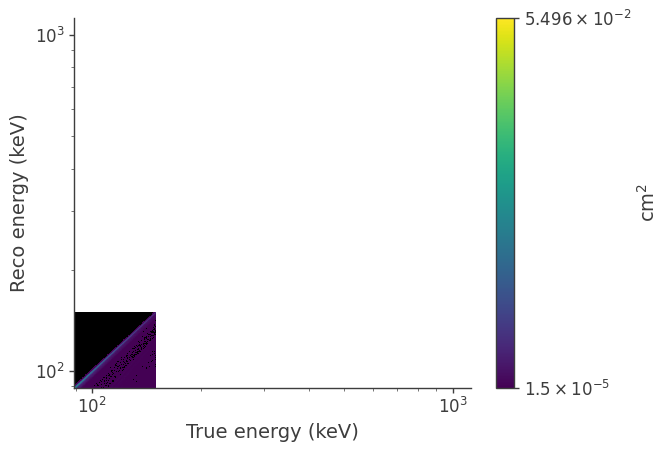

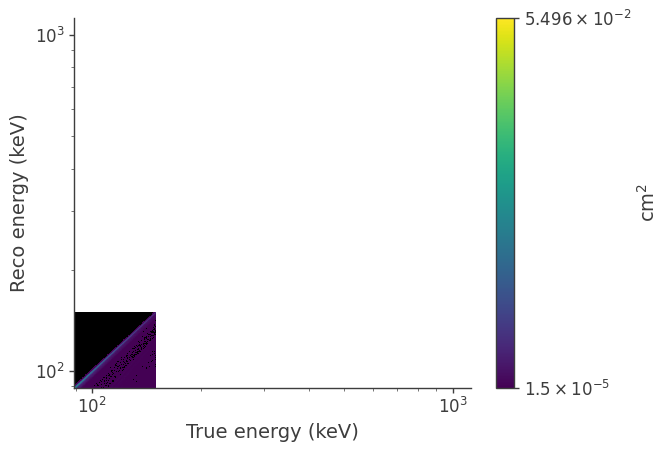

In [234]:
rsp.plot_matrix()

There is an issue with "rsp.plot_matrix()"; if the source code uses log scaling on the x and y axes, it displays like this. 
Try a custom script.

Note that "response.matrix" gives the full response matrix (DRM) with true photon energies on the y-axis and measured photon energies on the x-axis. 

To match the orientation of the matrix from Olivier to compare, plot the transpose of response.matrix.

In [235]:
def plot_drm(rmf_file, arf_file, plot=None): 
    
    response = OGIPResponse(rmf_file, arf_file)

    ebounds_centers = (response.ebounds[:-1] + response.ebounds[1:])/2. # centers of the measured energy bins
    mc_energies_centers = (response.monte_carlo_energies[:-1] + response.monte_carlo_energies[1:])/2. # centers of the true energy bins

    drm = response.matrix

    if plot==True:
        fig, ax = plt.subplots(1, 1, figsize=(8,7))
        
        im = ax.pcolormesh(ebounds_centers, mc_energies_centers, drm.T,
                           norm=LogNorm(vmin=1e-6, vmax=1),
                           cmap='viridis')

        ax.set_xlabel('Measured Energy [keV]')
        ax.set_ylabel('Photon Energy [keV]')
        ax.set_title('Reconstructed DRM')

        colorbar = fig.colorbar(im, ax=ax)
        colorbar.set_label('Instrument Response')
        plt.savefig('rmf_from_threeml.png', dpi=150)
        plt.show()

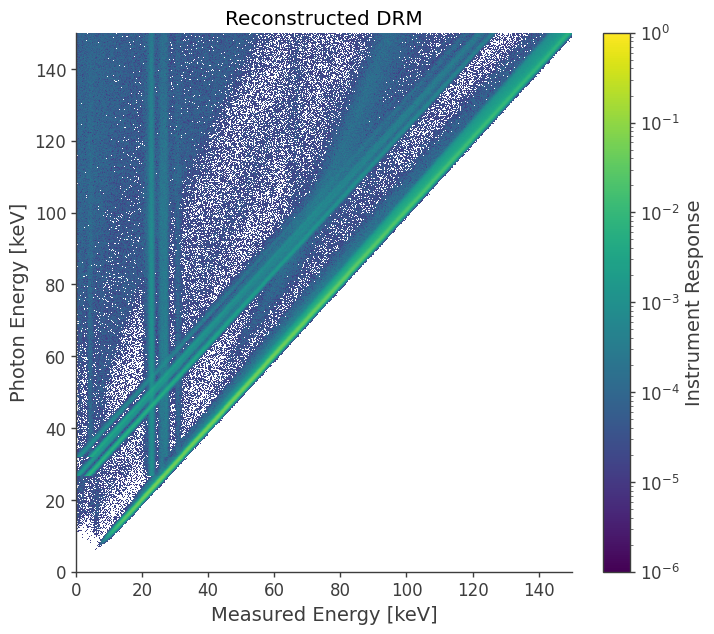

In [236]:
plot_drm(rmf_file, arf_file, plot=True)

Extract the Monte Carlo or photon energies and take their mean.

In [237]:
mean_mc_energy = np.mean( np.vstack((rsp.monte_carlo_energies[:-1],
                                     rsp.monte_carlo_energies[1:])).T,axis=1)

Take some of the rows from the channel side of the matrix.

In [238]:
data = [rsp.matrix[i,:] for i in range(0,128,4)]

In [42]:
#from python_tricks.stack_plot import stack_plot

fig = stack_plot(mean_mc_energy,
              *data,
              alpha=.7,
              scale=.1,
              x_scale='log',
              cmap='viridis_r')

ERROR: NameError: name 'stack_plot' is not defined [IPython.core.interactiveshell]
2025-09-16 16:21:36 - astroquery - ERROR: NameError: name 'stack_plot' is not defined


NameError: name 'stack_plot' is not defined

The "python_tricks" module is something that J. Michael Burgess developed. There is a link to it on his website, but that webpage does not contain any function called stack_plot. 

Try this instead: 

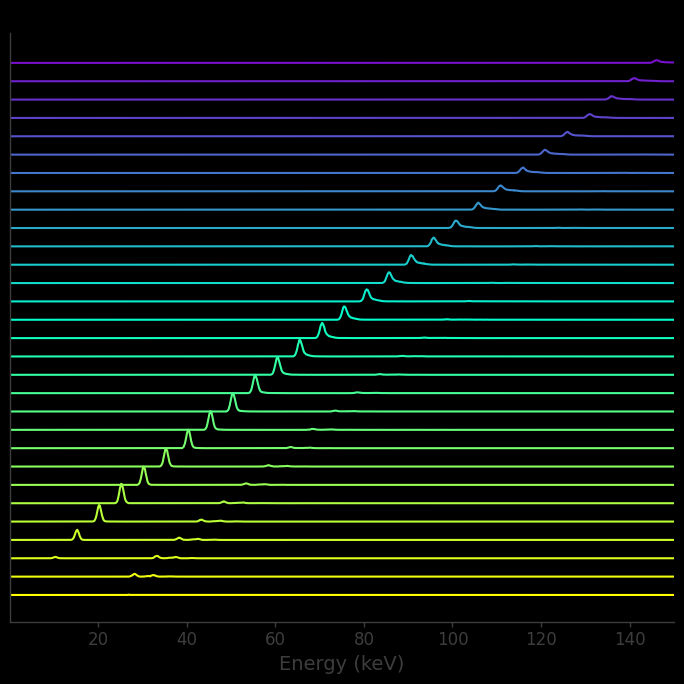

In [ ]:
'''
def create_waterfall_plot_from_response(response, step=1, 
                                      fig_size=(7, 7), 
                                      y_offset=0.05,
                                      black_background=True,
                                      line_width=1.5):
    # Extract response data
    matrix = response.matrix
    #bin_centers = (response.ebounds[:-1] + response.ebounds[1:])/2.
    n_rows = matrix.shape[0]
    
    # Calculate mean MC energy for each bin
    mean_mc_energy = np.mean(np.vstack((response.monte_carlo_energies[:-1], 
                                       response.monte_carlo_energies[1:])).T, axis=1)
    
    # Create indices of rows to plot
    indices = range(0, n_rows, step)
    
    # Create custom colormap: yellow -> turquoise -> purple
    colors = [(1, 1, 0),      # yellow
              (0, 1, 0.8),    # turquoise
              (0.5, 0, 0.8)]  # purple
    cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=fig_size)
    
    # Set black background if requested
    if black_background:
        fig.patch.set_facecolor('black')
        ax.set_facecolor('black')
        plt.rcParams.update({
            'text.color': 'white',
            'axes.labelcolor': 'white',
            'axes.edgecolor': 'white',
            'xtick.color': 'white',
            'ytick.color': 'white'
        })
    
    # Plot each selected row from the response matrix
    for idx, i in enumerate(indices):
        y_data = matrix[i, :]
        
        # Normalize color by position in energy range
        color_idx = i / (n_rows - 1) if n_rows > 1 else 0.5
        color = cmap(color_idx)
        
        offset = idx * y_offset
        ax.plot(mean_mc_energy, y_data + offset, color=color, lw=line_width)
    
    # Remove y ticks
    ax.set_yticks([])
    
    # Set axis labels and limits
    ax.set_xlabel('Energy (keV)')
    ax.set_title('Detector Response Matrix')
    
    # Focus on the main part of the response (adjust if needed)
    ax.set_xlim(mean_mc_energy.min(), mean_mc_energy.max())
    
    plt.tight_layout()
    return fig, ax

def plot_response_waterfall(rsp_file, arf_file=None, step=None):
    rsp = OGIPResponse(rsp_file=rsp_file, arf_file=arf_file)
    fig, ax = create_waterfall_plot_from_response(rsp, step=step)
    plt.show()
    return fig, ax

fig, ax = plot_response_waterfall(rsp_file=rmf_file, arf_file=arf_file, step=50)
plt.show()
'''

This demonstrtates why we cannot simply convert the measured count per energy spectrum into a photon spectrum, since we only know the true energy of any measured photon probabilistically. 

To find the true spectrum, we use a forward folding technique:

1. assume a photon model spectrum with a set a variable parameters
2. convolve this spectrum with the instrument response to produce counts in energy space
3. compare these trial counts with the observed counts statistically
4. iterate until a convergence criterion is met.

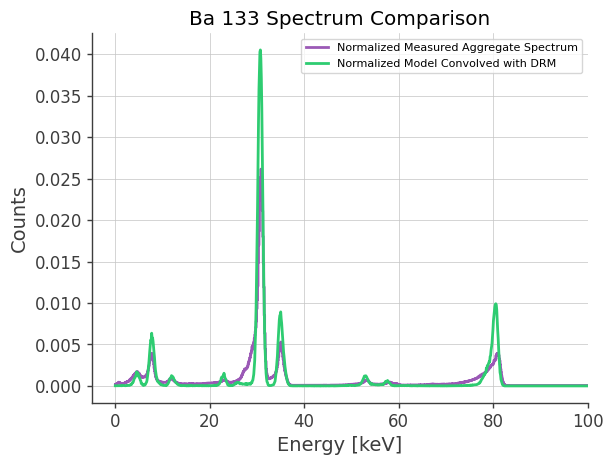

In [289]:
# 1. Define a model Ba133 spectrum to use. 
# Before switching to 3ML, I want to see if the following works and to make sure that I understand how to proceed. 
# This uses the original Ba 133 model provided by Olivier.

# The DRM is 1500 bins x 1500 bins, 0 to 150 keV, and therefore 0.1 keV per energy bin.
# Define the spectral emission lines of the Ba133 source by creating Dirac delta functions at known line locations.
model_energies = np.zeros(1500)
ba133_lines = [47, 306, 310, 351, 359, 532, 796, 810]
ba133_intensities = np.array([15.87, 33.8, 62.4, 18.24, 4.45, 2.14, 2.63, 33.31])/100.

for this_line, this_intensity in zip(ba133_lines, ba133_intensities): 
    model_energies[this_line] = this_intensity

# 2. Take the convolution of the modeled Ba133 spectrum with the DRM. 
 
folded_counts = np.dot(model_energies, drm.T)

# TODO: Verify this normalization.
#model_energies_norm = model_energies / np.sum(model_energies)
folded_counts_norm = folded_counts / np.sum(folded_counts)
hist_norm = hist / np.sum(hist)

# Plot the convolution of the modeled Ba133 spectrum with the DRM.
plt.step(bin_centers, hist_norm, where='mid', label='Normalized Measured Aggregate Spectrum')
plt.plot(rsp.monte_carlo_energies[:-1], folded_counts_norm, label = 'Normalized Model Convolved with DRM')
plt.title('Ba 133 Spectrum Comparison')
plt.xlabel('Energy [keV]')
plt.ylabel('Counts')
plt.xlim(-5,100)
plt.legend()
plt.grid()
plt.show()

The peaks do not overlap, but this could be because the measured spectrum is more spread out than the modeled spectrum...

Now, switching to 3ML... 

3ML does not have built-in support for Diraq delta functions. Instead, delta functions can be modelled using very narrow Gaussian distributions... 

In [ ]:
def fit_spec(cal_ph_list, filtered_ph_list, hist, rsp, int_time, asic, pixel, initial_background, plot_fit=None, plot_residuals=None): 
    # Define the measured spectrum
    hist, bin_centers, energy_min, energy_max, cal_spec = rebin_spec(filtered_ph_list, 
                                                                     rsp, num_bins=np.shape(rsp.matrix)[0], 
                                                                     asic=asic, pixel=pixel, plot=False)

    # Create observed spectrum. 
    
    # Since our data is not in the standard OGIP format, we can use the following method instead.
    # We can begin by defining a wrapper that contains the measured Ba133 spectrum.

    obs_spectrum = BinnedSpectrumWithDispersion(
        counts=hist,
        exposure=int_time,
        response=rsp,
    )
    obs_spectrum._errors = np.ones_like(hist)

    # Set up plugin. 
    # The DispersionSpectrumLike plugin expects the background to be an instance of threeML.data_spectrum.BinnedSpectrum. 
    # The "background" argument in the following plugin is intended for actual background measurements, not functions. 
    # Currently, "background" is defined as a constant function.
    plugin = DispersionSpectrumLike(
        name="Ba133_Measured_Spectrum",
        observation=obs_spectrum,
        background=None,
        verbose=False,
    )

    # Define the model to use. 
    # Define a constant background.
    background = Constant()
    background.k.value = initial_background
    background.k.bounds = (0, None)
    background.k.free = True

    # Define the Ba 133 spectral emission lines.
    ba133_lines_keV = np.array([4.7, 30.6, 31.0, 35.1, 35.9, 53.2, 79.6, 81.0])  # in keV
    ba133_intensities = np.array([15.87, 33.8, 62.4, 18.24, 4.45, 2.14, 2.63, 33.31]) / 100.0

    ba133_lines = []
    for i, (this_energy, this_intensity) in enumerate(zip(ba133_lines_keV, ba133_intensities)):
        line = Gaussian()
        line.mu.value = this_energy
        line.mu.fixed = True

        line.sigma.value = 0.01  # Approximate Dirac delta with very narrow Gaussian
        line.sigma.fixed = True

        line.F.value = this_intensity * 100
        line.F.bounds = (0, None)
        line.F.free = True

        ba133_lines.append(line)

    # Combine the background and the spectral emission lines with the background.
    total_model = background
    for this_line in ba133_lines: 
        total_model += this_line

   # total_lines = reduce(operator.add, ba133_lines)
   # total_model = background + total_lines

    # Create source and model
    source = PointSource("Ba133_Source_Spectrum", ra=0, dec=0, spectral_shape=total_model)
    model = Model(source)

    # Likelihood fit
    data_list = DataList(plugin)
    jl = JointLikelihood(model, data_list)

    fit_result = jl.fit(quiet=False)

    # Bayesian sampling (optional).
    if hasattr(jl, "sample"):
        print("➡ Running Bayesian sampling with emcee...")
        fit_result = jl.sample("emcee", nwalkers=50, burn_in=200, steps=1000)

    # Plot the best-fit spectrum and residuals.
    model_counts = plugin.get_model()

    if plot_fit:
        plt.figure(figsize=(10, 6))
        plt.scatter(bin_centers[:-1], hist[:-1], c='blue', s=0.8, label="Measured Spectrum")
        plt.plot(bin_centers[:-1], model_counts[:-1], color='red', linewidth=0.8, label="Best-fit Spectrum")
        for this_line in ba133_lines_keV:
            plt.axvline(this_line, color='gray', linewidth=0.8, linestyle='--', alpha=0.4)
        plt.xlabel("Energy (keV)")
        plt.ylabel("Counts")
        plt.title("Ba-133 Spectrum Fit with 3ML")
        plt.legend()
        plt.xlim(0, 100)
        plt.show()

    if plot_residuals:
        residuals = hist[:-1] - model_counts[:-1]
        plt.figure()
        plt.scatter(bin_centers[:-1], residuals, s=2.0)
        plt.axhline(0, color='black', linestyle='--')
        plt.xlabel("Energy (keV)")
        plt.ylabel("Residuals")
        plt.title("Fit Residuals")
        plt.xlim(0, 100)
        plt.show()

        plt.hist(residuals, bins=30, edgecolor='black')
        plt.title('Best-Fit Residuals')
        plt.xlabel('Residuals')
        plt.show()

    return fit_result

16:38:28 INFO      Auto-probed noise models:                                                    ]8;id=204431;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=841755;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py#490\490]8;;\

         INFO      - observation: gaussian                                                      ]8;id=213787;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=28451;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py#491\491]8;;\

         INFO      - background: None                                                           ]8;id=644530;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=489043;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py#492\492]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=880639;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=405683;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py#1046\1046]8;;\

16:38:33 WARNING   66.2 percent of samples have been thrown away because they failed the   ]8;id=837229;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=354837;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/analysis_results.py#1739\1739]8;;\
                  constraints on the parameters. This results might not be suitable for                            
                  error propagation. Enlarge the boundaries until you loose less than 1                            
                  percent of the samples.                                                                          

...

1.00,-0.01,-0.01,0.01,-0.00,-0.00,-0.00,0.02,0.03,0.03,-0.01,-0.01,0.01,0.01,-0.04,0.01,-0.01,0.01,-0.01,-0.01,0.01,0.01,-0.02,-0.00,0.01
-0.01,1.00,-0.41,0.41,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00,-0.00,0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00
-0.01,-0.41,1.00,0.64,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00,-0.00,0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00
0.01,0.41,0.64,1.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00
-0.00,-0.00,-0.00,0.00,1.00,-0.89,0.07,0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00,0.00,0.00,0.00,0.00
-0.00,-0.00,-0.00,0.00,-0.89,1.00,-0.49,0.03,0.04,0.04,-0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00
-0.00,-0.00,-0.00,0.00,0.07,-0.49,1.00,0.03,0.06,0.05,-0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00
0.02,-0.00,-0.00,0.00,0.00,0.03,0.03,1.00,0.85,0.89,-0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00
0.03,-0.00,-0.00,0.00,0.00,0.04,0.06,0.85,1.00,0.59,-0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00
0.03,-0.00,-0.00,0.00,0.00,0.04,0.05,0.89,0.59,1.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00
-0.01,0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,1.00,-0.43,0.41,-0.02,0.03,-0.02,0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
Ba133_Measured_Spectrum,420.069759
total,420.069759


Values of statistical measures:

,statistical measures
AIC,891.021471
BIC,1022.970027


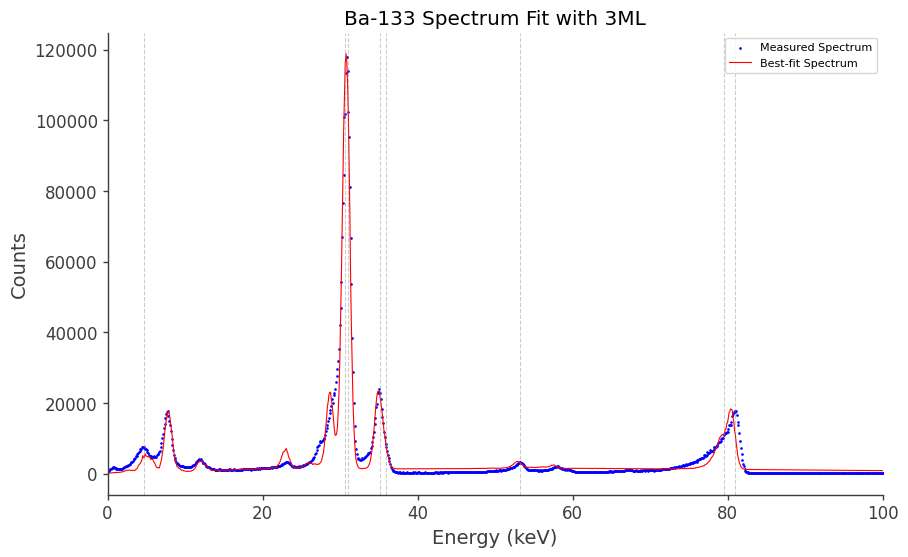

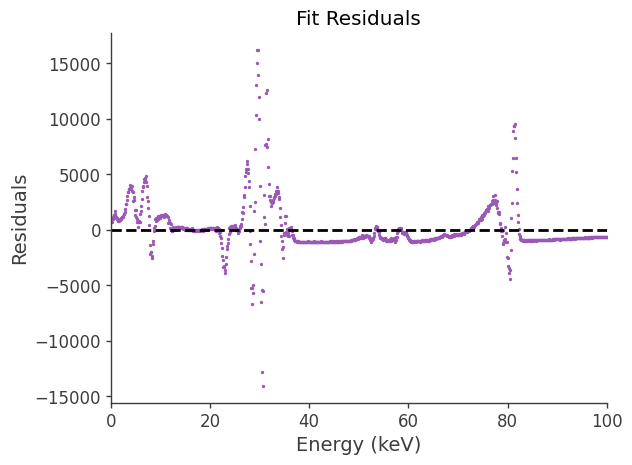

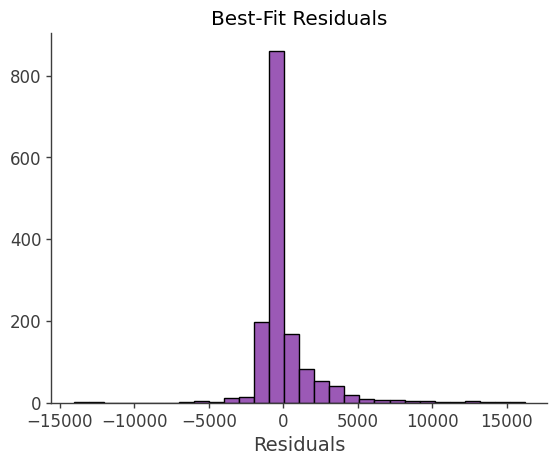

(                                                         value  \
 Ba133_Source_Spectrum.spectrum.main.composite.k_1     6.985194   
 Ba133_Source_Spectrum.spectrum.main.composite.F_2    15.423195   
 Ba133_Source_Spectrum.spectrum.main.composite.mu_2   28.867877   
 Ba133_Source_Spectrum.spectrum.main.composite.s...    0.002334   
 Ba133_Source_Spectrum.spectrum.main.composite.F_3    56.981478   
 Ba133_Source_Spectrum.spectrum.main.composite.mu_3   30.617791   
 Ba133_Source_Spectrum.spectrum.main.composite.s...    0.001436   
 Ba133_Source_Spectrum.spectrum.main.composite.F_4    55.986026   
 Ba133_Source_Spectrum.spectrum.main.composite.mu_4   31.021201   
 Ba133_Source_Spectrum.spectrum.main.composite.s...    0.000745   
 Ba133_Source_Spectrum.spectrum.main.composite.F_5    68.091895   
 Ba133_Source_Spectrum.spectrum.main.composite.mu_5   35.120177   
 Ba133_Source_Spectrum.spectrum.main.composite.s...    0.004826   
 Ba133_Source_Spectrum.spectrum.main.composite.F_6   368.75446

In [293]:
fit_spec(cal_ph_list, 
         filtered_ph_list, 
         hist=hist,
         rsp=rsp,
         int_time=int_time,
         asic=None, 
         pixel=None,
         initial_background=2.5,
         plot_fit=True,
         plot_residuals=True)

In [294]:
def fit_spec(cal_ph_list, filtered_ph_list, rsp, asic, pixel, initial_background, initial_line_energies, plot_fit=None, plot_residuals=None): 
    
    # Define the measured spectrum to fit. 
    hist, bin_centers, energy_min, energy_max, cal_spec = rebin_spec(filtered_ph_list, 
                                                                     rsp, 
                                                                     num_bins=np.shape(rsp.matrix)[0], 
                                                                     asic=asic, pixel=pixel, plot=True)
    
    # Create the spectrum. 
    obs_spectrum = BinnedSpectrumWithDispersion(
        counts=hist,
        exposure=int_time,
        response=rsp,
    )

    obs_spectrum._errors = np.ones_like(hist) # placeholder; if this key is undefined, creates an error.  

    plugin = DispersionSpectrumLike(
        name="Ba133_Measured_Spectrum",
        observation=obs_spectrum,
        background=None, 
        verbose=True,
    )

    # Create the model.
    background = Constant(k=initial_background)
    background.k.bounds = (0, None)
    background.k.frozen = False

    # Initial guesses for the sigma, energy, and amplitude for each Barium 133 spectral emission line. 
    # Remember, our goal here is to create a model for the source, which is independent of detector effects! 

    initial_sigmas = np.ones(8)*0.05
    print(f'initial_sigmas: {initial_sigmas}')

    # Initial guess for the amplitudes. 
    # Quick and dirty: find the amplitudes of each spectral emission line by defining an roi around the energy of each spectral emission line, and finding the maximum value of counts within that region.
    rois = []
    for this_line_energy in initial_line_energies: 
        this_roi = [this_line_energy - 0.1, this_line_energy + 0.1]
        #print(this_roi)
        rois.append(this_roi)

    initial_amps = []
    for this_roi in rois:  
        this_idx = (bin_centers < this_roi[1]) & (bin_centers > this_roi[0])
        #print(this_idx)
        #print(f'max of hist[idx]: {np.amax(hist[this_idx])}')
        initial_amps.append(np.amax(hist[this_idx]))
    print(f'initial_amps: {initial_amps}')

    gaussians = []
    for this_amp, this_energy, this_sigma in zip(initial_amps, initial_line_energies, initial_sigmas):
        g = Gaussian()

        safe_amp = max(this_amp, 10)
        g.F.value = safe_amp
        g.F.min_value = 0.01
        g.F.max_value = safe_amp * 10
        g.F.frozen = False

        mu_span = max(this_energy * 0.4, 10.0)
        g.mu.value = this_energy
        g.mu.min_value = max(this_energy - mu_span, 0.1)
        g.mu.max_value = this_energy + mu_span
        g.mu.frozen = True

        g.sigma.value = max(this_sigma, 1.0)
        g.sigma.min_value = 0.1
        g.sigma.max_value = 50.0
        g.sigma.frozen = True

        print(f"Line @ {this_energy:.2f} keV: F={safe_amp:.2f}, μ∈[{g.mu.min_value:.2f}, {g.mu.max_value:.2f}], σ={g.sigma.value:.2f}")
        gaussians.append(g)

    # Sum Gaussians + background
    total_model = background 
    for g in gaussians:
        total_model += g

    source = PointSource("Ba133_Source_Spectrum", 
                         ra=0, 
                         dec=0, 
                         spectral_shape=total_model) # the source spectrum. 
    model = Model(source)

    data_list = DataList(plugin) 
    jl = JointLikelihood(model, data_list)

    fit_result = jl.fit(quiet=False)

    model_counts = plugin.get_model()

    if plot_fit == True: 
        plt.figure(figsize=(10, 6))

        # plot the measured result and the best-fit result. 
        plt.scatter(bin_centers[:-1], hist[:-1], c='blue', s=0.8, label="Measured Spectrum")
        plt.plot(bin_centers[:-1], model_counts[:-1], color='red', linewidth=0.8, label="Best Fit Model (folded)")
    
        # Uncomment to overplot the initial guesses for the amplitudes of each spectral emission line.
        plt.scatter(initial_line_energies, initial_amps, c='orange')

        # Uncomment this block to overplot the initial guesses for the standard deviations of each spectral emission line.
        #for this_line_energy, this_sigma in zip(initial_line_energies, initial_sigmas): 
        #    plt.axvspan(this_line_energy - this_sigma, this_line_energy + this_sigma, color='blue', alpha=0.3)

        for this_line in initial_line_energies: 
            plt.axvline(this_line, color='grey', alpha=0.3)

        for this_roi in rois: 
            plt.axvspan(this_roi[0], this_roi[1], alpha=0.3)

        plt.xlabel("Energy (keV)")
        plt.ylabel("Counts")
        plt.title("Ba-133 Spectrum Fit with 3ML")
        plt.legend()
        plt.xlim(0,100)
        plt.show()

    if plot_residuals == True: 
        # plot the residuals to assess the goodness of the fit.
        residuals = hist[:-1] - model_counts[:-1]
        dev_residuals = np.std(residuals)
        print(dev_residuals)

        plt.figure()
        plt.scatter(bin_centers[:-1], residuals, s=0.8, label="Residuals")
        plt.axhline(0, color='gray', linestyle='-')
        plt.xlabel("Energy (keV)")
        plt.ylabel("Best-Fit Residuals")
        plt.legend()
        plt.xlim(0,100)
        plt.show()

        plt.hist(residuals, bins=30, edgecolor='black')
        plt.title('Best-Fit Residuals')
        plt.xlabel('Residuals')
        plt.show()

    return fit_result

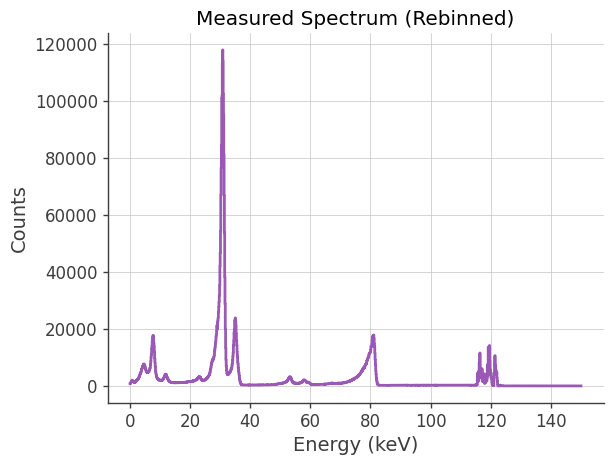

16:44:41 INFO      Auto-probed noise models:                                                    ]8;id=593597;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=282600;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py#490\490]8;;\

         INFO      - observation: gaussian                                                      ]8;id=540852;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=942362;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py#491\491]8;;\

         INFO      - background: None                                                           ]8;id=465721;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=125696;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py#492\492]8;;\

initial_sigmas: [0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05]
initial_amps: [np.int64(101757), np.int64(113869), np.int64(23846), np.int64(17673)]
Line @ 30.63 keV: F=101757.00, μ∈[18.38, 42.88], σ=1.00
Line @ 30.97 keV: F=113869.00, μ∈[18.58, 43.36], σ=1.00
Line @ 35.05 keV: F=23846.00, μ∈[21.03, 49.07], σ=1.00
Line @ 81.00 keV: F=17673.00, μ∈[48.60, 113.40], σ=1.00


         INFO      set the minimizer to minuit                                             ]8;id=373874;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=616672;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py#1046\1046]8;;\

...

1.00,-0.22,-0.00,-0.13,-0.28,-0.01,-0.23,0.03,0.07,0.00,-0.34,0.13,-0.23
-0.22,1.00,-0.10,0.65,-0.05,-0.08,-0.08,0.07,0.05,0.00,0.07,-0.03,0.05
-0.00,-0.10,1.00,-0.15,0.08,0.06,0.09,-0.06,-0.05,-0.00,-0.00,0.00,-0.00
-0.13,0.65,-0.15,1.00,-0.09,-0.09,-0.11,0.09,0.06,0.00,0.04,-0.02,0.03
-0.28,-0.05,0.08,-0.09,1.00,0.52,0.65,-0.70,-0.20,-0.00,0.08,-0.03,0.06
-0.01,-0.08,0.06,-0.09,0.52,1.00,0.24,-0.76,-0.14,-0.00,0.01,-0.00,0.00
-0.23,-0.08,0.09,-0.11,0.65,0.24,1.00,-0.29,-0.52,-0.00,0.06,-0.02,0.04
0.03,0.07,-0.06,0.09,-0.70,-0.76,-0.29,1.00,0.09,0.00,-0.01,0.00,-0.01
0.07,0.05,-0.05,0.06,-0.20,-0.14,-0.52,0.09,1.00,-0.00,-0.02,0.01,-0.01
0.00,0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,1.00,-0.00,0.00,-0.00
-0.34,0.07,-0.00,0.04,0.08,0.01,0.06,-0.01,-0.02,-0.00,1.00,-0.37,0.68


Values of -log(likelihood) at the minimum:

,-log(likelihood)
Ba133_Measured_Spectrum,187.977458
total,187.977458


Values of statistical measures:

,statistical measures
AIC,402.199869
BIC,471.026781


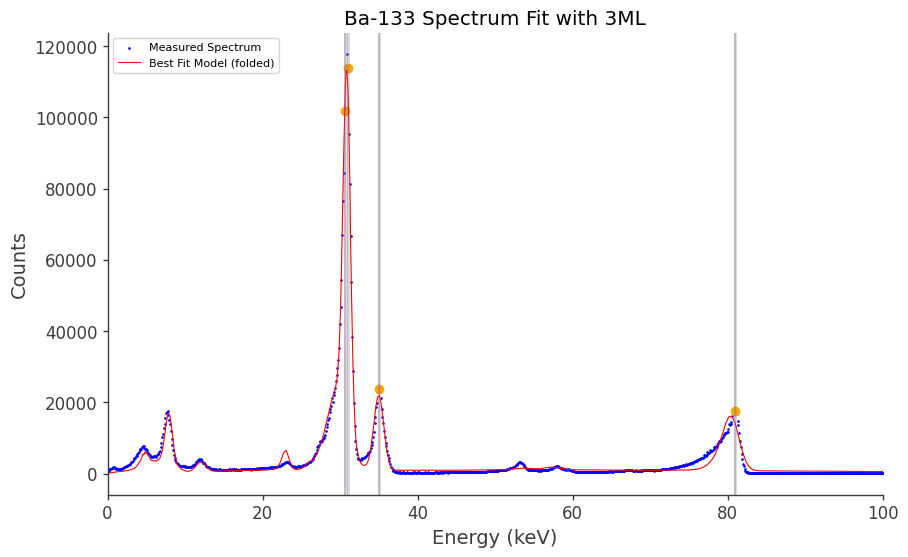

1406.4169169879913


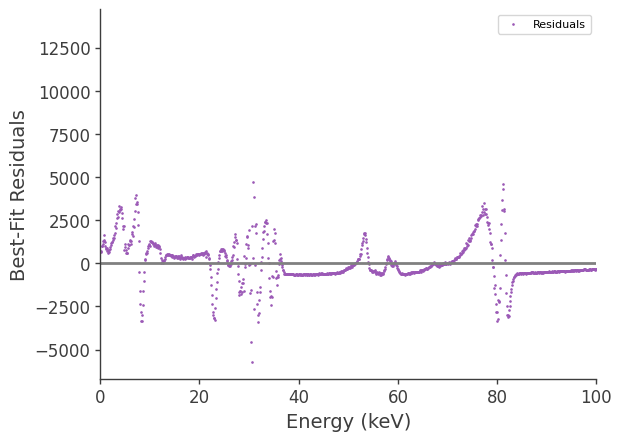

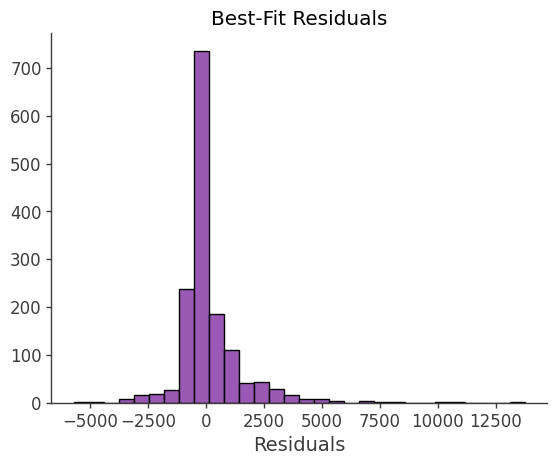

(                                                         value  \
 Ba133_Source_Spectrum.spectrum.main.composite.k_1     4.802932   
 Ba133_Source_Spectrum.spectrum.main.composite.F_2   214.485905   
 Ba133_Source_Spectrum.spectrum.main.composite.mu_2   35.227973   
 Ba133_Source_Spectrum.spectrum.main.composite.s...    0.454128   
 Ba133_Source_Spectrum.spectrum.main.composite.F_3   468.435842   
 Ba133_Source_Spectrum.spectrum.main.composite.mu_3   29.851282   
 Ba133_Source_Spectrum.spectrum.main.composite.s...    1.327497   
 Ba133_Source_Spectrum.spectrum.main.composite.F_4   704.824830   
 Ba133_Source_Spectrum.spectrum.main.composite.mu_4   31.060806   
 Ba133_Source_Spectrum.spectrum.main.composite.s...    0.100000   
 Ba133_Source_Spectrum.spectrum.main.composite.F_5   297.135961   
 Ba133_Source_Spectrum.spectrum.main.composite.mu_5   81.094213   
 Ba133_Source_Spectrum.spectrum.main.composite.s...    0.879282   
 
                                                     negativ

In [295]:
fit_spec(cal_ph_list, filtered_ph_list, rsp, asic=None, pixel=None,
         initial_background=2.5,
         initial_line_energies=[30.6254, 30.9731, 35.053, 80.9979],
         plot_fit=True,
         plot_residuals=True)

16:45:19 INFO      Auto-probed noise models:                                                    ]8;id=908338;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=118490;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py#490\490]8;;\

         INFO      - observation: gaussian                                                      ]8;id=496886;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=595880;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py#491\491]8;;\

         INFO      - background: None                                                           ]8;id=93642;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=65639;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py#492\492]8;;\

Fitting 4 Lorentzian line(s)
🔹 Line 1 @ 30.625 keV (init amp: 101757.00)
🔹 Line 2 @ 30.973 keV (init amp: 113869.00)
🔹 Line 3 @ 35.053 keV (init amp: 23846.00)
🔹 Line 4 @ 80.998 keV (init amp: 17673.00)

Available parameters:
 - Ba133_Lorentz_Source.position.ra
 - Ba133_Lorentz_Source.position.dec
 - Ba133_Lorentz_Source.spectrum.main.composite.a_1
 - Ba133_Lorentz_Source.spectrum.main.composite.b_1
 - Ba133_Lorentz_Source.spectrum.main.composite.F_2
 - Ba133_Lorentz_Source.spectrum.main.composite.mu_2
 - Ba133_Lorentz_Source.spectrum.main.composite.gamma_2
 - Ba133_Lorentz_Source.spectrum.main.composite.F_3
 - Ba133_Lorentz_Source.spectrum.main.composite.mu_3
 - Ba133_Lorentz_Source.spectrum.main.composite.gamma_3
 - Ba133_Lorentz_Source.spectrum.main.composite.F_4
 - Ba133_Lorentz_Source.spectrum.main.composite.mu_4
 - Ba133_Lorentz_Source.spectrum.main.composite.gamma_4
 - Ba133_Lorentz_Source.spectrum.main.composite.F_5
 - Ba133_Lorentz_Source.spectrum.main.composite.mu_5
 - Ba133_

         INFO      set the minimizer to minuit                                             ]8;id=790233;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=952856;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py#1046\1046]8;;\

...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
Ba133_Lorentz_Spectrum,73.922481
total,73.922481


Values of statistical measures:

,statistical measures
AIC,176.127790
BIC,250.230047


This version of 3ML does not support `jl.sample()`.


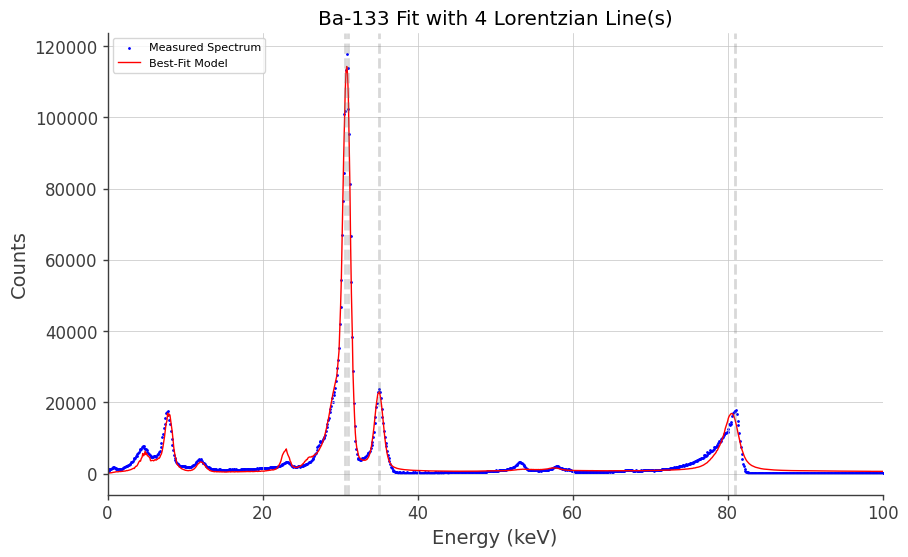

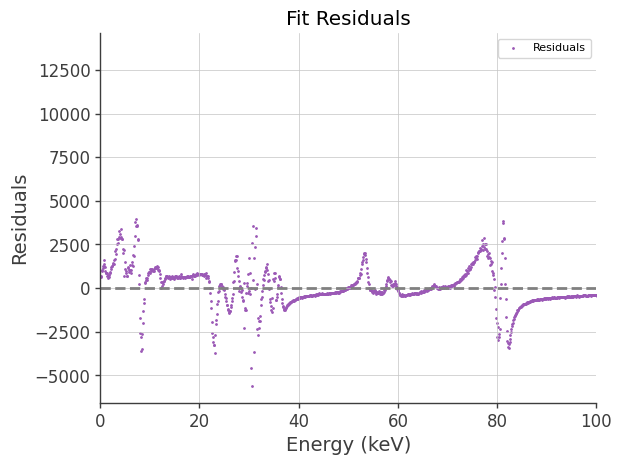

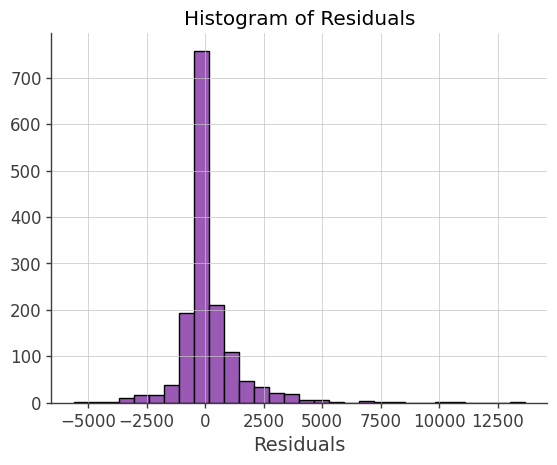

In [296]:
# Linear background and Lorentzian fits (instead of Gaussian) for the spectral emission lines. 

from astromodels.functions.functions_1D.polynomials import Line
from threeML import *
from astromodels.functions.function import Function1D, FunctionMeta

class Lorentzian1D_Custom(Function1D, metaclass=FunctionMeta):
    """
    description: Custom Lorentzian line shape with total area normalization.

    parameters:
      F:
        desc: Total area under the Lorentzian curve
        type: real
        initial value: 1.0
      mu:
        desc: Central energy of the line
        type: real
        initial value: 1.0
      gamma:
        desc: Half-width at half-maximum (HWHM) of the line
        type: real
        initial value: 1.0
    """

    def _set_units(self, x_unit, y_unit):
        self.F.unit = y_unit * x_unit
        self.mu.unit = x_unit
        self.gamma.unit = x_unit

    def evaluate(self, x, F, mu, gamma):
        return (F / np.pi) * (gamma / ((x - mu)**2 + gamma**2))


def fit_spec(cal_ph_list, filtered_ph_list, rsp, asic, pixel,
             initial_background, initial_line_energies,
             num_lines=1, plot_fit=False, plot_residuals=False):
    
    # Build histogram and time info
    hist, bin_centers, energy_min, energy_max, cal_spec = rebin_spec(
        filtered_ph_list, rsp, num_bins=np.shape(rmf)[0],
        asic=asic, pixel=pixel, plot=False
    )
    
    time = cal_ph_list.event_list['time']
    int_time = (Time(time[-1]) - Time(time[0])).to_value('sec')

    # Background model: LINEAR
    background = Line()
    background.a.value = initial_background
    background.a.min_value = 0.0
    background.a.max_value = np.max(hist) * 2
    background.a.frozen = False

    background.b.value = 0.0
    background.b.min_value = -5.0
    background.b.max_value = +5.0
    background.b.frozen = False

    # Observation
    obs_spectrum = BinnedSpectrumWithDispersion(
        counts=hist,
        exposure=int_time,
        response=rsp,
    )
    obs_spectrum._errors = np.ones_like(hist)  # flat errors

    plugin = DispersionSpectrumLike(
        name="Ba133_Lorentz_Spectrum",
        observation=obs_spectrum,
        background=None,
        verbose=True,
    )

    # Limit number of lines
    num_lines = max(1, min(num_lines, len(initial_line_energies)))
    print(f"Fitting {num_lines} Lorentzian line(s)")

    # Build Lorentzian models
    lorentzians = []
    for i in range(num_lines):
        energy = initial_line_energies[i]
        roi = [energy - 0.1, energy + 0.1]
        idx_roi = (bin_centers < roi[1]) & (bin_centers > roi[0])
        initial_amp = np.amax(hist[idx_roi])
        safe_amp = max(initial_amp, 10)

        l = Lorentzian1D_Custom()
        l.F.value = safe_amp
        l.F.min_value = 0.001
        l.F.max_value = np.max(hist) * 50
        l.F.frozen = False

        l.mu.value = energy
        l.mu.min_value = energy - 10.0
        l.mu.max_value = energy + 10.0
        l.mu.frozen = False

        l.gamma.value = 0.5
        l.gamma.min_value = 0.001
        l.gamma.max_value = 20.0
        l.gamma.frozen = False

        print(f"🔹 Line {i+1} @ {energy:.3f} keV (init amp: {safe_amp:.2f})")
        lorentzians.append(l)

    # Composite model: sum all lines + background
    total_model = background
    for l in lorentzians:
        total_model += l

    source = PointSource(
        "Ba133_Lorentz_Source",
        ra=0, dec=0,
        spectral_shape=total_model
    )
    model = Model(source)

    print("\nAvailable parameters:")
    for pname in model.parameters.keys():
        print(" -", pname)

    from threeML import Uniform_prior

    # Now assign priors to parameters of the model
    model.Ba133_Lorentz_Source.spectrum.main.composite.a_1.prior = Uniform_prior(lower_bound=background.a.min_value, upper_bound=background.a.max_value)
    model.Ba133_Lorentz_Source.spectrum.main.composite.b_1.prior = Uniform_prior(lower_bound=background.b.min_value, upper_bound=background.b.max_value)

    for i in range(num_lines):
        lorentzian_name = f"F{i+1}"  # You might need to get the correct param names here
        l = lorentzians[i]
        model.Ba133_Lorentz_Source.spectrum.main.composite[f'F_{i+2}'].prior = Uniform_prior(lower_bound=l.F.min_value, upper_bound=l.F.max_value)
        model.Ba133_Lorentz_Source.spectrum.main.composite[f'mu_{i+2}'].prior = Uniform_prior(lower_bound=l.mu.min_value, upper_bound=l.mu.max_value)
        model.Ba133_Lorentz_Source.spectrum.main.composite[f'gamma_{i+2}'].prior = Uniform_prior(lower_bound=l.gamma.min_value, upper_bound=l.gamma.max_value)

    # Likelihood
    data_list = DataList(plugin)
    jl = JointLikelihood(model, data_list)
    fit_result = jl.fit(quiet=False)

    # Bayesian sampling (optional)
    if hasattr(jl, "sample"):
        print("➡ Running Bayesian sampling...")
        fit_result = jl.sample("emcee", nwalkers=100, burn_in=500, steps=2000)

        analysis = jl.results.analysis
        total_samples = sum([len(v.samples) for v in analysis.values()])
        rejected = sum([v.rejected_samples for v in analysis.values()])
        percent_rejected = 100 * rejected / total_samples
        print(f"Rejected samples: {rejected}/{total_samples} ({percent_rejected:.1f}%)")

        if percent_rejected > 1.0:
            print("Consider widening parameter bounds.")
        else:
            print("Sampling bounds look OK.")
    else:
        print("This version of 3ML does not support `jl.sample()`.")

    # Optional goodness-of-fit
    model_counts = plugin.get_model()

    # Plot fit
    if plot_fit:
        plt.figure(figsize=(10, 6))
        plt.scatter(bin_centers[:-1], hist[:-1], s=1.0, label="Measured Spectrum", color='blue')
        plt.plot(bin_centers[:-1], model_counts[:-1], color='red', label="Best-Fit Model", lw=1)
        for energy in initial_line_energies[:num_lines]:
            plt.axvline(energy, color='gray', linestyle='--', alpha=0.3)
        plt.xlabel("Energy (keV)")
        plt.ylabel("Counts")
        plt.title(f"Ba-133 Fit with {num_lines} Lorentzian Line(s)")
        plt.legend()
        plt.xlim(0, 100)
        plt.grid(True)
        plt.show()

    # Plot residuals
    if plot_residuals:
        residuals = hist[:-1] - model_counts[:-1]
        plt.figure()
        plt.scatter(bin_centers[:-1], residuals, s=1.0, label="Residuals")
        plt.axhline(0, color='gray', linestyle='--')
        plt.xlabel("Energy (keV)")
        plt.ylabel("Residuals")
        plt.title("Fit Residuals")
        plt.legend()
        plt.grid(True)
        plt.xlim(0, 100)
        plt.show()

        plt.hist(residuals, bins=30, edgecolor='black')
        plt.title("Histogram of Residuals")
        plt.xlabel("Residuals")
        plt.grid(True)
        plt.show()

fit_spec(cal_ph_list, filtered_ph_list, rsp, asic=None, pixel=None,
         initial_background=2.5,
         initial_line_energies=[30.6254, 30.9731, 35.053, 80.9979],
         num_lines=4,
         plot_fit=True,
         plot_residuals=True)